# **Employee Attrition Prediction By Aditya Zalte-DS**

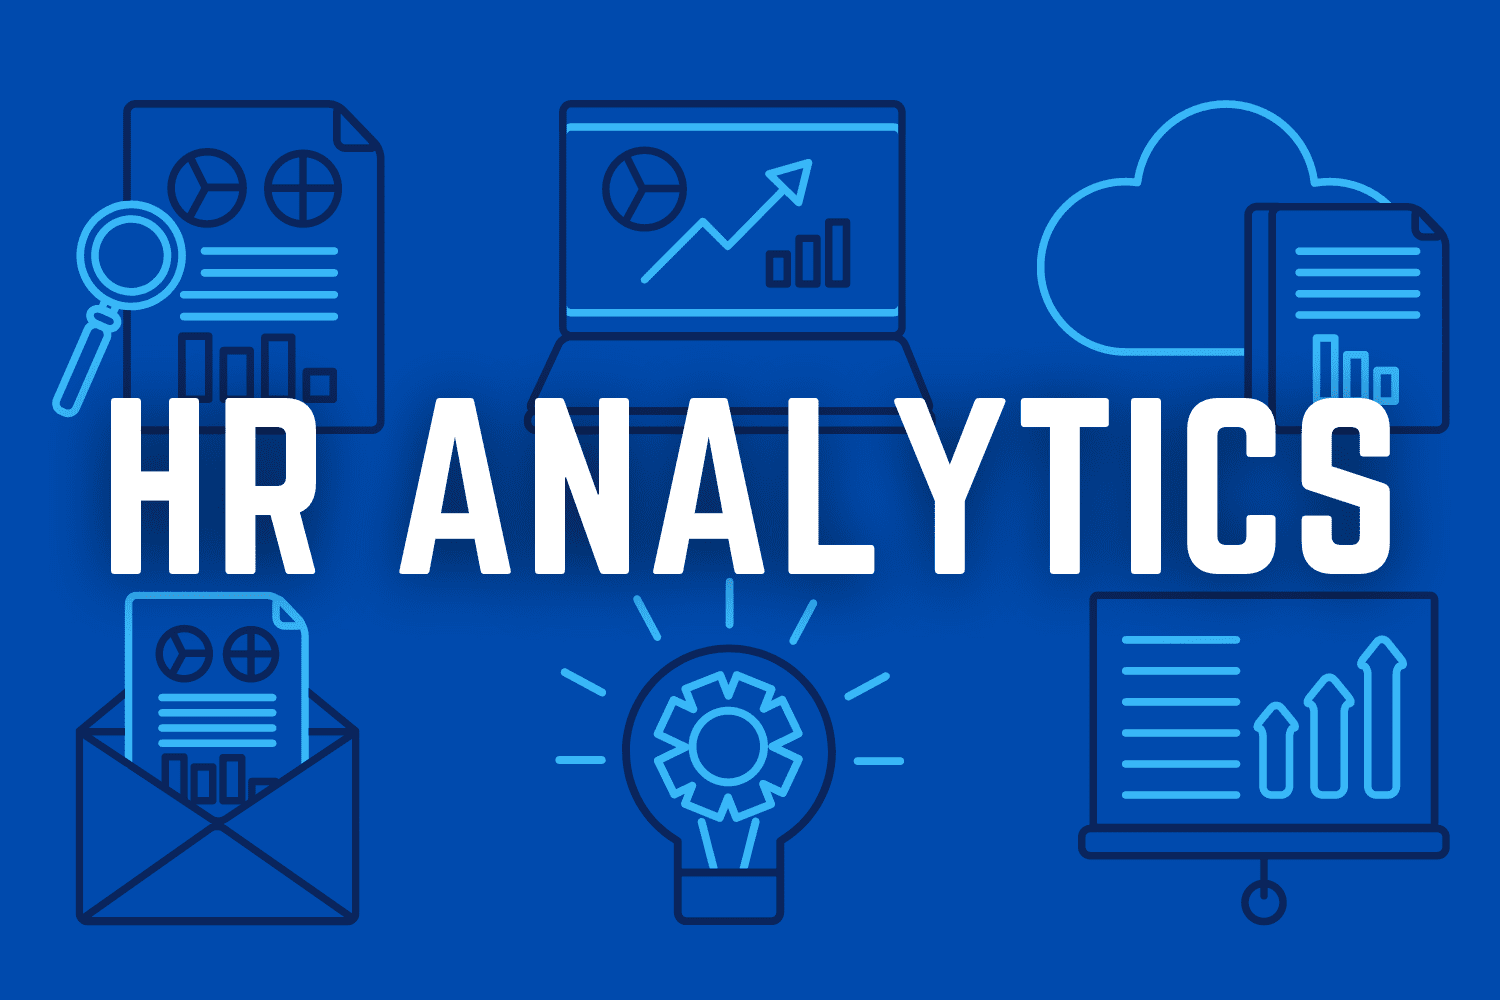

# **An Introduction**
<p align="justify">
HR analytics is the process of collecting and analyzing Human Resource (HR) data in order to improve an organization’s workforce performance. The process can also be referred to as talent analytics, people analytics, or even workforce analytics.
This method of data analysis takes data that is routinely collected by HR and correlates it to HR and organizational objectives. Doing so provides measured evidence of how HR initiatives are contributing to the organization’s goals and strategies.

**Need of HR Analytics** Most organizations already have data that is routinely collected, so why the need for a specialized form of analytics? Can HR not simply look at the data they already have?
Unfortunately, raw data on its own cannot actually provide any useful insight. It would be like looking at a large spreadsheet full of numbers and words.
Once organized, compared and analyzed, this raw data provides useful insight.They can help answer questions like:

* What patterns can be revealed in employee turnover?
* How long does it take to hire employees?
* What amount of investment is needed to get employees up to a fully productive speed?
* Which of our employees are most likely to leave within the year?
* Are learning and development initiatives having an impact on employee performance?

**The process of HR Analytics**

HR Analytics is made up of several components that feed into each other.

* To gain the problem-solving insights that HR Analytics promises, data must first be collected.
* The data then needs to be monitored and measured against other data, such as historical information, norms or averages.
* This helps identify trends or patterns. It is at this point that the results can be analyzed at the analytical stage.
* The final step is to apply insight to organizational decisions.

So lets start with our analysis!!!
</p>


In [30]:
# Import Main Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [31]:
# Read the Dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [32]:
data=pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# **🧹Exploratory Data Analysis (EDA) on Dataset**


In [33]:
# Cheking the Data
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [34]:
# checking DataTypes
data.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [35]:
# checking the Null values, if we will remove it.
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


# **Analysis Section📊**

# **How does Work duration in current role impact Attrition?**

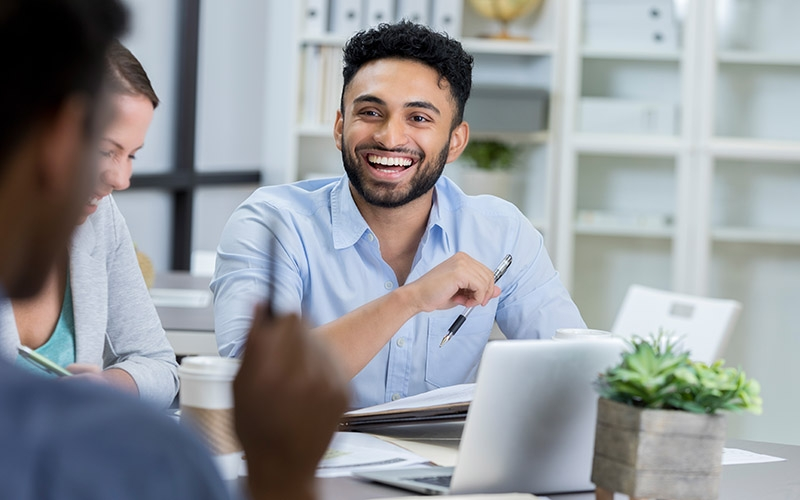

In [36]:
yrscr_att=data.groupby(['YearsInCurrentRole','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(yrscr_att,x='YearsInCurrentRole',y='Counts',color='Attrition',title='Counts of People working for years in an Organization')

/tmp/ipython-input-2027160588.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.





> **Observation:**
> The analysis indicates that employee attrition is higher during the initial years of service in a particular role. As employees gain experience and remain in the same position for a longer duration, their likelihood of leaving the organization decreases. This trend suggests that career progression or promotion opportunities play an important role in employee retention.


## **How does the environment satisfaction impact attrition?**

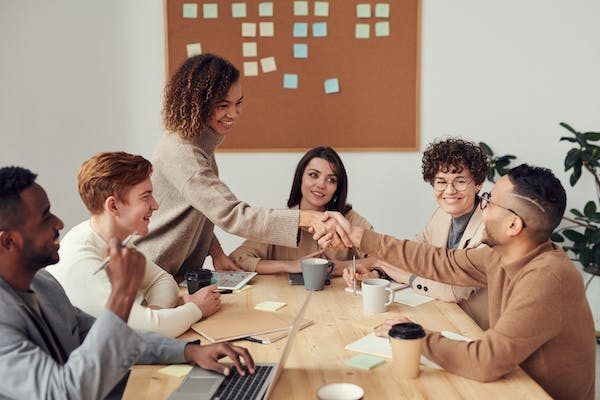

In [37]:
sats_att=data.groupby(['EnvironmentSatisfaction','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.area(sats_att,x='EnvironmentSatisfaction',y='Counts',color='Attrition',title='Environment Satisfaction level Counts of People in an Organization')

/tmp/ipython-input-2089262791.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.





> **Observation:**
> The analysis shows that when employee satisfaction levels range between 1 and 2, the likelihood of attrition slightly decreases, suggesting that employees remain hopeful about improvement within the organization. However, as satisfaction levels increase from 2 to 3, attrition tends to rise, indicating that employees may seek better opportunities elsewhere. At higher satisfaction levels, the attrition rate remains nearly constant, implying stability among highly satisfied employees.


# **Do managers play a role in why employees leave the organization?**

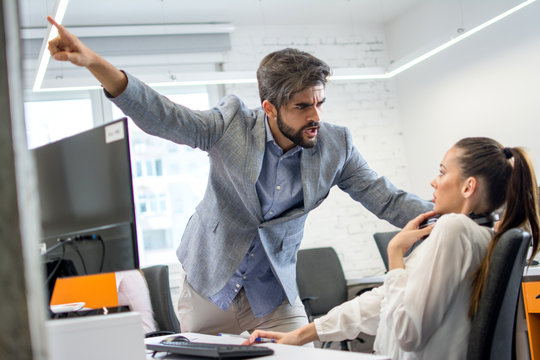

In [38]:
man_att=data.groupby(['YearsWithCurrManager','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(man_att,x='YearsWithCurrManager',y='Counts',color='Attrition',title='Count of people spending years with a Manager in an Organization')

/tmp/ipython-input-2564066298.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.





> **Observation:** The analysis reveals three noticeable spikes in attrition rates when examining the employee–manager relationship. In the initial stage, when the time spent with the manager is minimal, employees are more likely to leave—possibly influenced by experiences with previous managers or adjustment challenges. Around the two-year mark, attrition rises again as employees seek growth or improvement opportunities. Another increase is observed after approximately seven years, where employees may perceive limited career progression and opt for a change. Conversely, when employees have spent a long duration with the same manager, satisfaction levels tend to be high, resulting in a significantly lower likelihood of resignation.


# **Does company stocks for employees impact attrition?**



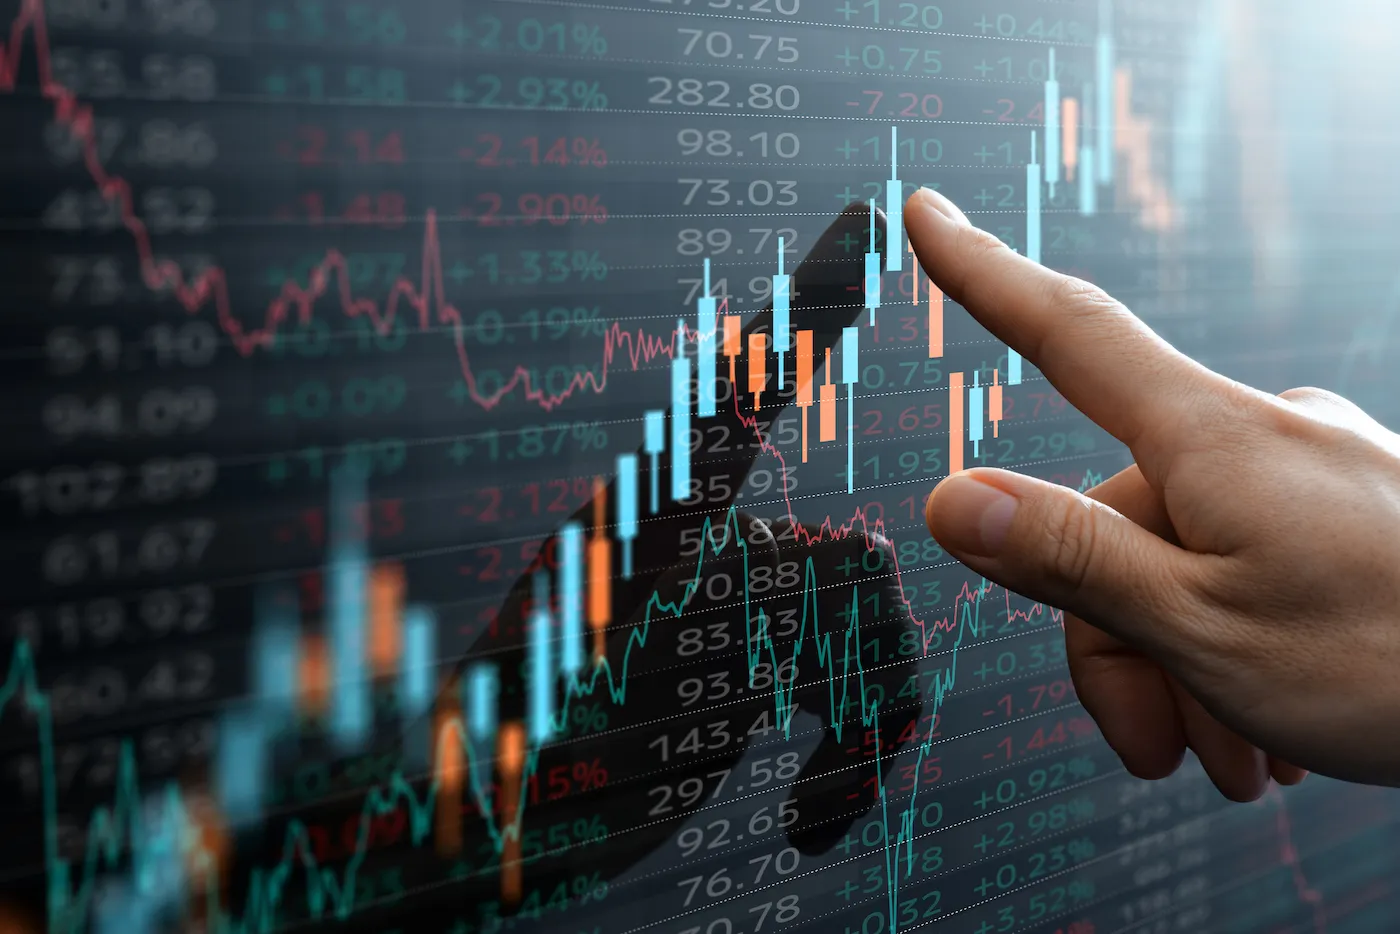



In [39]:
stock_att=data.groupby(['StockOptionLevel','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.bar(stock_att,x='StockOptionLevel',y='Counts',color='Attrition',title='Stock facilities level wise People in an Organization')

/tmp/ipython-input-4188274414.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



**Observation** The tendency of employees to leave the organization is much more when the stock availing options are limited. Since the stocks constitute to a huge amount of money while staying for a few years, people do not want to lose that opportunity. People with very limited/no stcok options have a freedom to leave the organization at will.

# **What is the relationship between employee age and attrition rate?**

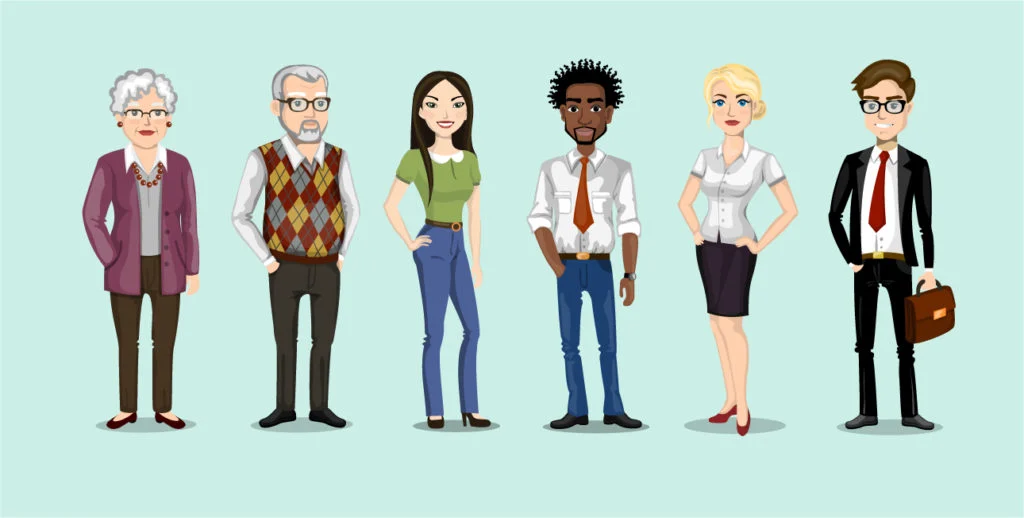

In [40]:
age_att=data.groupby(['Age','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(age_att,x='Age',y='Counts',color='Attrition',title='Agewise Counts of People in an Organization')

/tmp/ipython-input-1387603831.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.






>  **Observation:** The analysis indicates that employee attrition is highest among individuals aged 28 to 32. As age increases, the attrition rate steadily declines, reflecting a stronger preference for job stability at later stages of life. At very young ages, particularly between 18 and 20, employees are more likely to leave as they are still exploring career options and opportunities. The trend begins to stabilize around the age of 21, marking a balance point where attrition starts to decline.


# **Is salary a key factor contributing to employee attrition?**

In [41]:
rate_att=data.groupby(['MonthlyIncome','Attrition']).apply(lambda x:x['MonthlyIncome'].count()).reset_index(name='Counts')
rate_att['MonthlyIncome']=round(rate_att['MonthlyIncome'],-3)
rate_att=rate_att.groupby(['MonthlyIncome','Attrition']).apply(lambda x:x['MonthlyIncome'].count()).reset_index(name='Counts')
fig=px.line(rate_att,x='MonthlyIncome',y='Counts',color='Attrition',title='Monthly Income basis counts of People in an Organization')
fig.show()

/tmp/ipython-input-3887719621.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipython-input-3887719621.py:3: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.






>**Observation:** The analysis reveals that attrition rates are significantly higher among employees earning lower incomes, particularly below ₹5,000 per month. As income levels rise, attrition gradually declines. However, a slight spike is observed around the ₹10,000 range, suggesting that employees in this income bracket may seek better opportunities to improve their standard of living. At higher income levels, the attrition rate remains relatively stable and low, indicating that financial satisfaction contributes to employee retention.


# **What is the relationship between department type and employee attrition rate?**

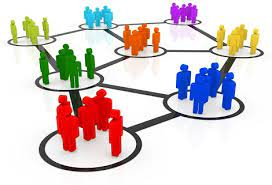

In [42]:
dept_att=data.groupby(['Department','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
fig=px.bar(dept_att,x='Department',y='Counts',color='Attrition',title='Department wise Counts of People in an Organization')
fig.show()

/tmp/ipython-input-2922417100.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.






>**Observation:** The chart illustrates that the Research & Development department employs the largest number of people, followed by the Sales department, while Human Resources has the fewest employees. Although R&D has the highest overall headcount, its attrition proportion is relatively lower compared to Sales. The Sales department exhibits a noticeably higher attrition ratio, indicating that employees in sales roles are more likely to leave the organization. The Human Resources department shows minimal attrition, possibly due to its smaller size and relatively stable workforce.


# **Does Hike percentage impact Attrition?**

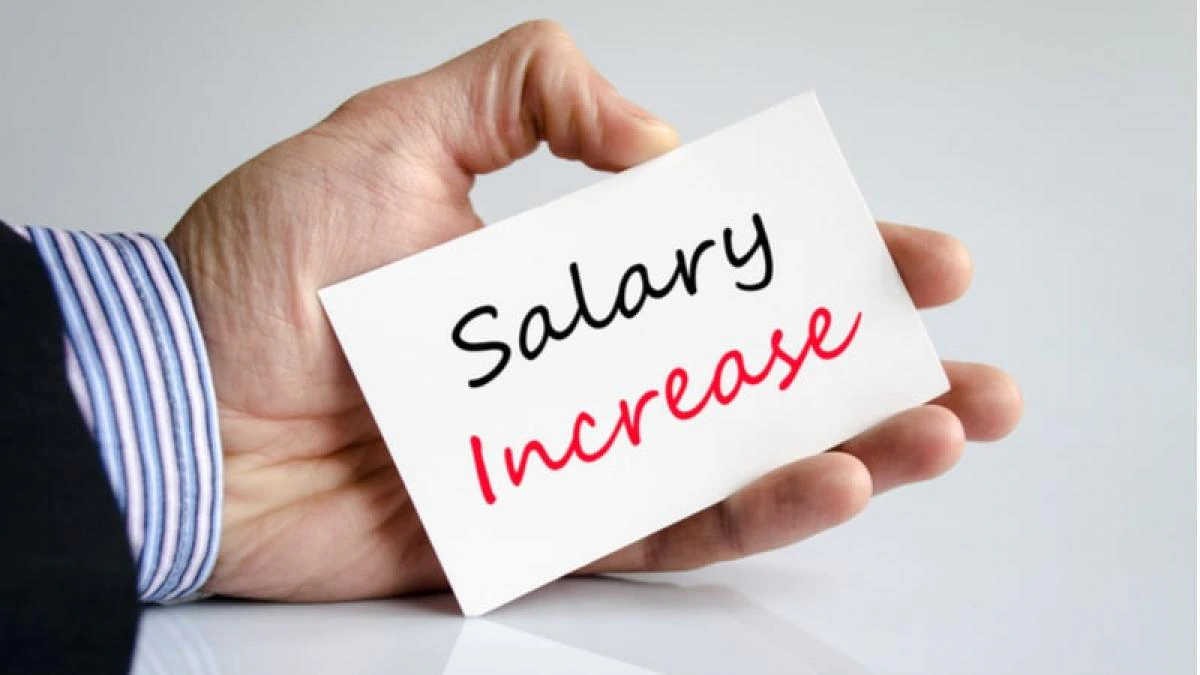

In [43]:
hike_att=data.groupby(['PercentSalaryHike','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.line(hike_att,x='PercentSalaryHike',y='Counts',color='Attrition',title='Count of Hike Percentages people receive in an Organization')

/tmp/ipython-input-1295749504.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.





**Observation:**
From the chart, it is clear that attrition is higher among employees who receive smaller salary hikes (between 11–14%). As the hike percentage increases, the count of employees leaving the organization steadily declines. This indicates that low salary increments contribute to dissatisfaction, motivating employees to look for better opportunities. On the other hand, employees receiving higher hikes (above 18%) tend to stay longer, suggesting that competitive salary growth helps reduce attrition and improve retention.



# **Does total work experience influence employee attrition?**

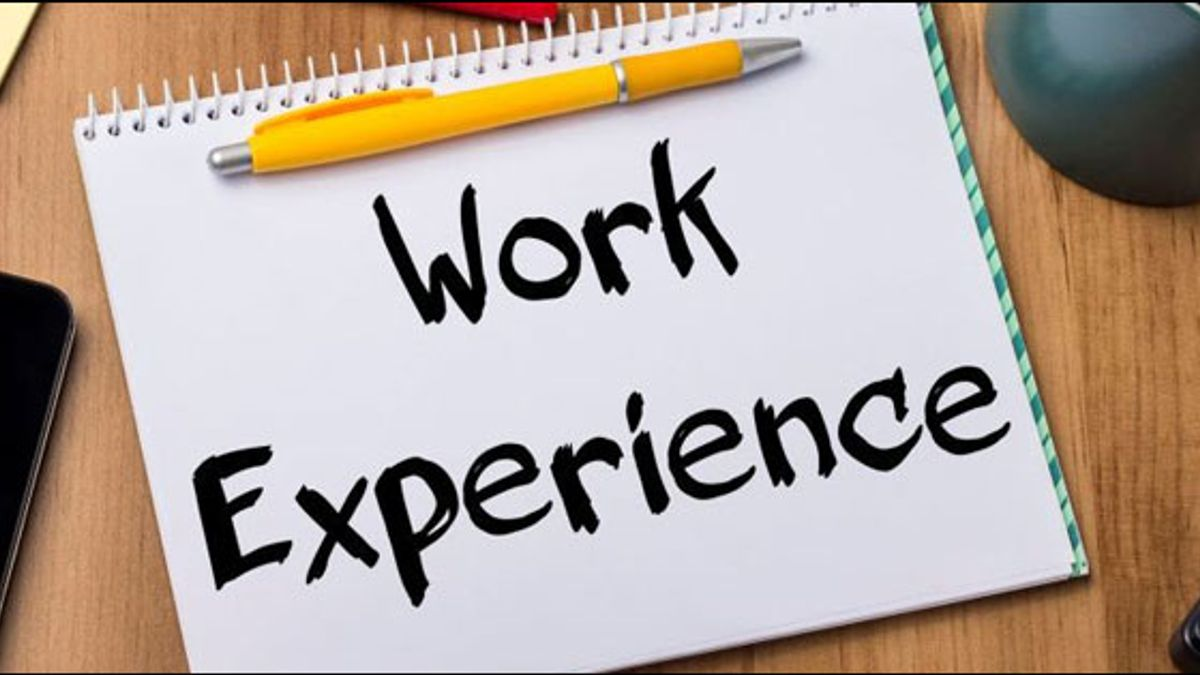

In [44]:
ncwrd_att=data.groupby(['NumCompaniesWorked','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.area(ncwrd_att,x='NumCompaniesWorked',y='Counts',color='Attrition',title='Work Experience level Counts of People in an Organization')


/tmp/ipython-input-3248696059.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



**Observation** Employees who have worked in fewer companies (especially 0–1) show higher attrition rates. This indicates that individuals early in their careers tend to switch jobs more frequently, possibly to explore better opportunities or align with their career goals. However, as the number of companies worked increases, attrition tends to stabilize — implying that employees with broader work experience are more likely to stay longer in an organization, having already explored multiple workplaces.



# **How does Work-Life Balance influence employee attrition trends?**

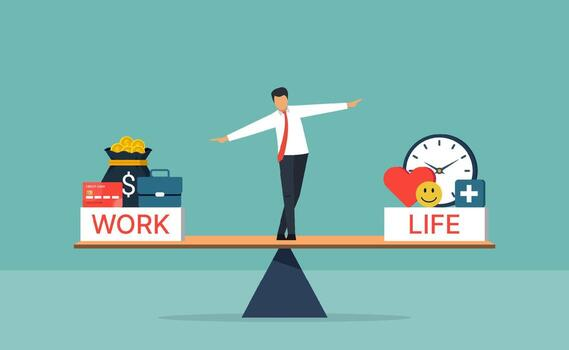

In [45]:
data=pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
wlb_att=data.groupby(['WorkLifeBalance','Attrition']).apply(lambda x:x['DailyRate'].count()).reset_index(name='Counts')
px.bar(wlb_att,x='WorkLifeBalance',y='Counts',color='Attrition',title='Work Life Balance level Counts of People in an Organization')

/tmp/ipython-input-807947909.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.





> **Observation:**
> The chart shows that most employees have a work-life balance score of 3, with a noticeable portion experiencing attrition within this group. Employees with very low work-life balance (score 1) also show some level of attrition, though their overall count is smaller. At higher work-life balance levels (score 4), both the number of employees and the attrition rate drop significantly. This pattern suggests that while moderate work-life balance levels are most common, improving work-life balance beyond a certain point can contribute to better employee retention and lower attrition rates.


# **📈Predicition Section**

Let’s evaluate how effectively we can predict an employee’s likelihood of staying with or leaving the organization based on all the given input features.

**Algorithm Used:** Logistic Regression


<Axes: >

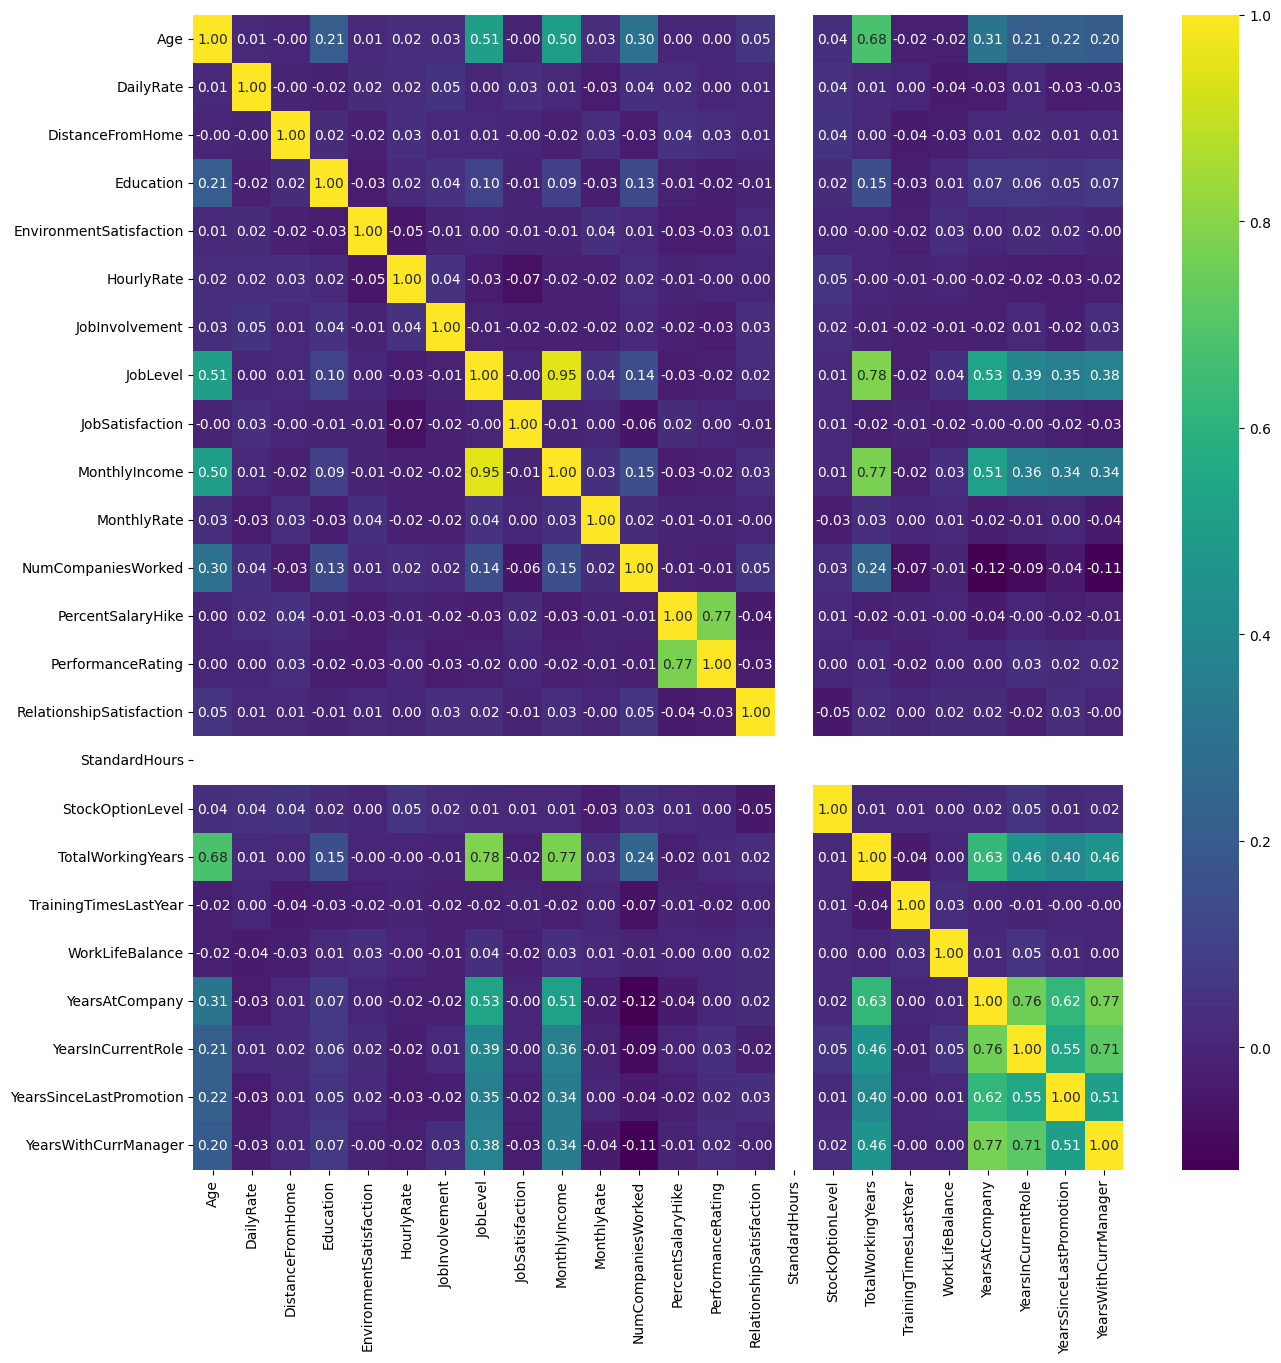

In [46]:
X=data[['Age', 'DailyRate',
       'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction',
        'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction','StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']]
y=data[['Attrition']].values.ravel()
plt.figure(figsize=(15,15))
sns.heatmap(X.corr(),annot=True,fmt='.2f',cmap='viridis')

In [47]:
X=data[['Age', 'DailyRate',
       'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction',
        'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction','StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']]
y=data[['Attrition']].values.ravel()
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)
log_reg=LogisticRegression(C=1000,max_iter=10000)
log_reg.fit(X_train,y_train)
print('--------------------------------------------------------------------------')
print('Logistic Regression:')
print('Traning Model accruracy scores: {:.3f}'.format(log_reg.score(X_train,y_train)))
print('Test Model accruracy scores: {:.3f}'.format(log_reg.score(X_test,y_test)))
print('--------------------------------------------------------------------------')

--------------------------------------------------------------------------
Logistic Regression:
Traning Model accruracy scores: 0.864
Test Model accruracy scores: 0.837
--------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



**Observation:**
The model achieved an accuracy of approximately **83%**, which is a strong starting point for predicting employee attrition. However, there is still room for improvement. In the next phase, we will focus on enhancing the model’s efficiency and accuracy by refining feature selection, tuning hyperparameters, and experimenting with more advanced algorithms.


In [48]:
data_dummies=pd.get_dummies(data)
features=data_dummies[['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single', 'Over18_Y',
       'OverTime_No', 'OverTime_Yes']]
X=features.values
y=data_dummies[['Attrition_Yes']].values.ravel()
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)
log_reg=LogisticRegression(C=1000,max_iter=10000)
log_reg.fit(X_train,y_train)
print('--------------------------------------------------------------------------')
print('Logistic Regression:')
print('Traning Model accruracy scores: {:.3f}'.format(log_reg.score(X_train,y_train)))
print('Test Model accruracy scores: {:.3f}'.format(log_reg.score(X_test,y_test)))
print('--------------------------------------------------------------------------')

--------------------------------------------------------------------------
Logistic Regression:
Traning Model accruracy scores: 0.895
Test Model accruracy scores: 0.889
--------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



**Observation:**
The model’s accuracy has now improved to approximately **88%**, showing significant progress from the initial version. However, this remains a **work in progress**, and further refinement is planned to enhance performance even more. Future updates will focus on advanced tuning, additional feature engineering, and exploring more complex models to achieve higher precision. Feedback and suggestions for further improvement are welcome in the comments section.


# **💡Summary**



**🔎Observations and Insights**

After analyzing the data, we derived the following key insights regarding employee attrition and job stability patterns:

1. **Career Stage and Job Switching:**
   Employees tend to switch jobs more frequently at the **early stages** of their careers. Once they gain stability—either professionally or personally—they prefer to **stay longer within the same organization**, often pursuing **vertical growth** rather than changing companies.

2. **Impact of Compensation and Stock Options:**
   **Higher salaries and stock options** serve as strong retention factors. Employees receiving better financial rewards demonstrate greater **loyalty and long-term association** with the company.

3. **Work-Life Balance Influence:**
   While a healthy **work-life balance** enhances employee satisfaction, some individuals with balanced work-life conditions still **seek better opportunities** for higher standards of living or professional advancement.

4. **Departmental Attrition Trends:**
   **Sales and target-driven roles** exhibit higher attrition rates due to performance pressure and goal dependency. In contrast, **administrative roles** such as Human Resources show **lower turnover rates**.

5. **Job and Environment Satisfaction:**
   **Job satisfaction** and **work environment quality** play critical roles in retention. Employees who feel valued and satisfied with their roles are significantly **less likely to leave**, whereas dissatisfaction with current projects strongly correlates with higher attrition.

---

**Data Highlights**

1. The dataset is exceptionally **clean and well-structured**, allowing for smooth analysis — appreciation to the dataset creator.
2. However, the data is **limited in scope**, covering only three departments. Including more departments and data from **multiple organizations** could help generate broader and more **generalizable insights**.

